In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from openstl.models import SimVP_Model

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

z_path = "all_z.npy"
save_dir = "simvp_zonly_results_stride5"
best_model_path = os.path.join(save_dir, "best_simvp_zonly_10to10.pt")

checkpoint = torch.load(best_model_path, map_location=device)

input_len = checkpoint["input_len"]
pred_len = checkpoint["pred_len"]
H = checkpoint["H"]
W = checkpoint["W"]
z_min = checkpoint["z_min"]
z_max = checkpoint["z_max"]

print("Loaded checkpoint from epoch:", checkpoint["epoch"])
print("Best val loss:", checkpoint["val_loss"])
print("input_len:", input_len)
print("pred_len:", pred_len)
print("H, W:", H, W)

device: cuda
Loaded checkpoint from epoch: 29
Best val loss: 0.00023672875111168694
input_len: 10
pred_len: 10
H, W: 128 128


In [2]:
# Load and normalize data

z_raw = np.load(z_path).astype(np.float32)
z_all = (z_raw - z_min) / (z_max - z_min + 1e-8)

print("z_all:", z_all.shape)
print("normalized min:", z_all.min())
print("normalized max:", z_all.max())

z_all: (10, 120, 128, 128)
normalized min: -0.010673165
normalized max: 1.0


In [3]:
# Recreate model and load weights

model = SimVP_Model(
    in_shape=(input_len, 1, H, W),
    hid_S=64,
    hid_T=256,
    N_S=4,
    N_T=8,
    model_type="gSTA",
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Model loaded.")

Model loaded.


In [4]:
# Autoregressive rollout function

def rollout_model(model, init_X, num_blocks):
    """
    init_X: (B, 10, 1, H, W)
    returns: (B, num_blocks*10, 1, H, W)
    """
    preds = []
    current = init_X

    model.eval()
    with torch.no_grad():
        for _ in range(num_blocks):
            pred = model(current)
            preds.append(pred)
            current = pred

    return torch.cat(preds, dim=1)

In [5]:
# Predict frame 10-119 from frame 0-9

test_sim = 9
start_t = 0
num_blocks = 11  # 11 blocks x 10 frames = 110 future frames

init_np = z_all[test_sim, 0:10]       # frame 0-9
target_np = z_all[test_sim, 10:120]   # frame 10-119

init_X = torch.from_numpy(init_np[:, None, :, :]).float().unsqueeze(0).to(device)
target_110 = torch.from_numpy(target_np[:, None, :, :]).float().unsqueeze(0).to(device)

pred_110 = rollout_model(model, init_X, num_blocks=num_blocks)

print("init_X:", init_X.shape)
print("pred_110:", pred_110.shape)
print("target_110:", target_110.shape)

mse = torch.mean((pred_110 - target_110) ** 2).item()
mae = torch.mean(torch.abs(pred_110 - target_110)).item()
rmse = mse ** 0.5

print(f"110-frame rollout MSE : {mse:.8f}")
print(f"110-frame rollout MAE : {mae:.8f}")
print(f"110-frame rollout RMSE: {rmse:.8f}")

init_X: torch.Size([1, 10, 1, 128, 128])
pred_110: torch.Size([1, 110, 1, 128, 128])
target_110: torch.Size([1, 110, 1, 128, 128])
110-frame rollout MSE : 0.01858724
110-frame rollout MAE : 0.10604085
110-frame rollout RMSE: 0.13633503


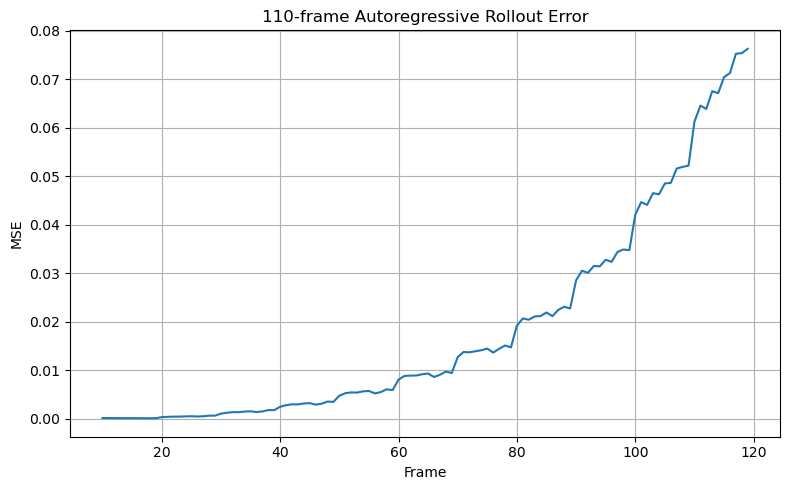

In [6]:
# Error per frame

pred_110_cpu = pred_110.cpu().squeeze(0)        # (110,1,H,W)
target_110_cpu = target_110.cpu().squeeze(0)    # (110,1,H,W)

mse_per_frame_110 = ((pred_110_cpu - target_110_cpu) ** 2).mean(dim=(1, 2, 3)).numpy()

frames = np.arange(10, 120)

plt.figure(figsize=(8, 5))
plt.plot(frames, mse_per_frame_110)
plt.xlabel("Frame")
plt.ylabel("MSE")
plt.title("110-frame Autoregressive Rollout Error")
plt.grid(True)
plt.tight_layout()
plt.show()

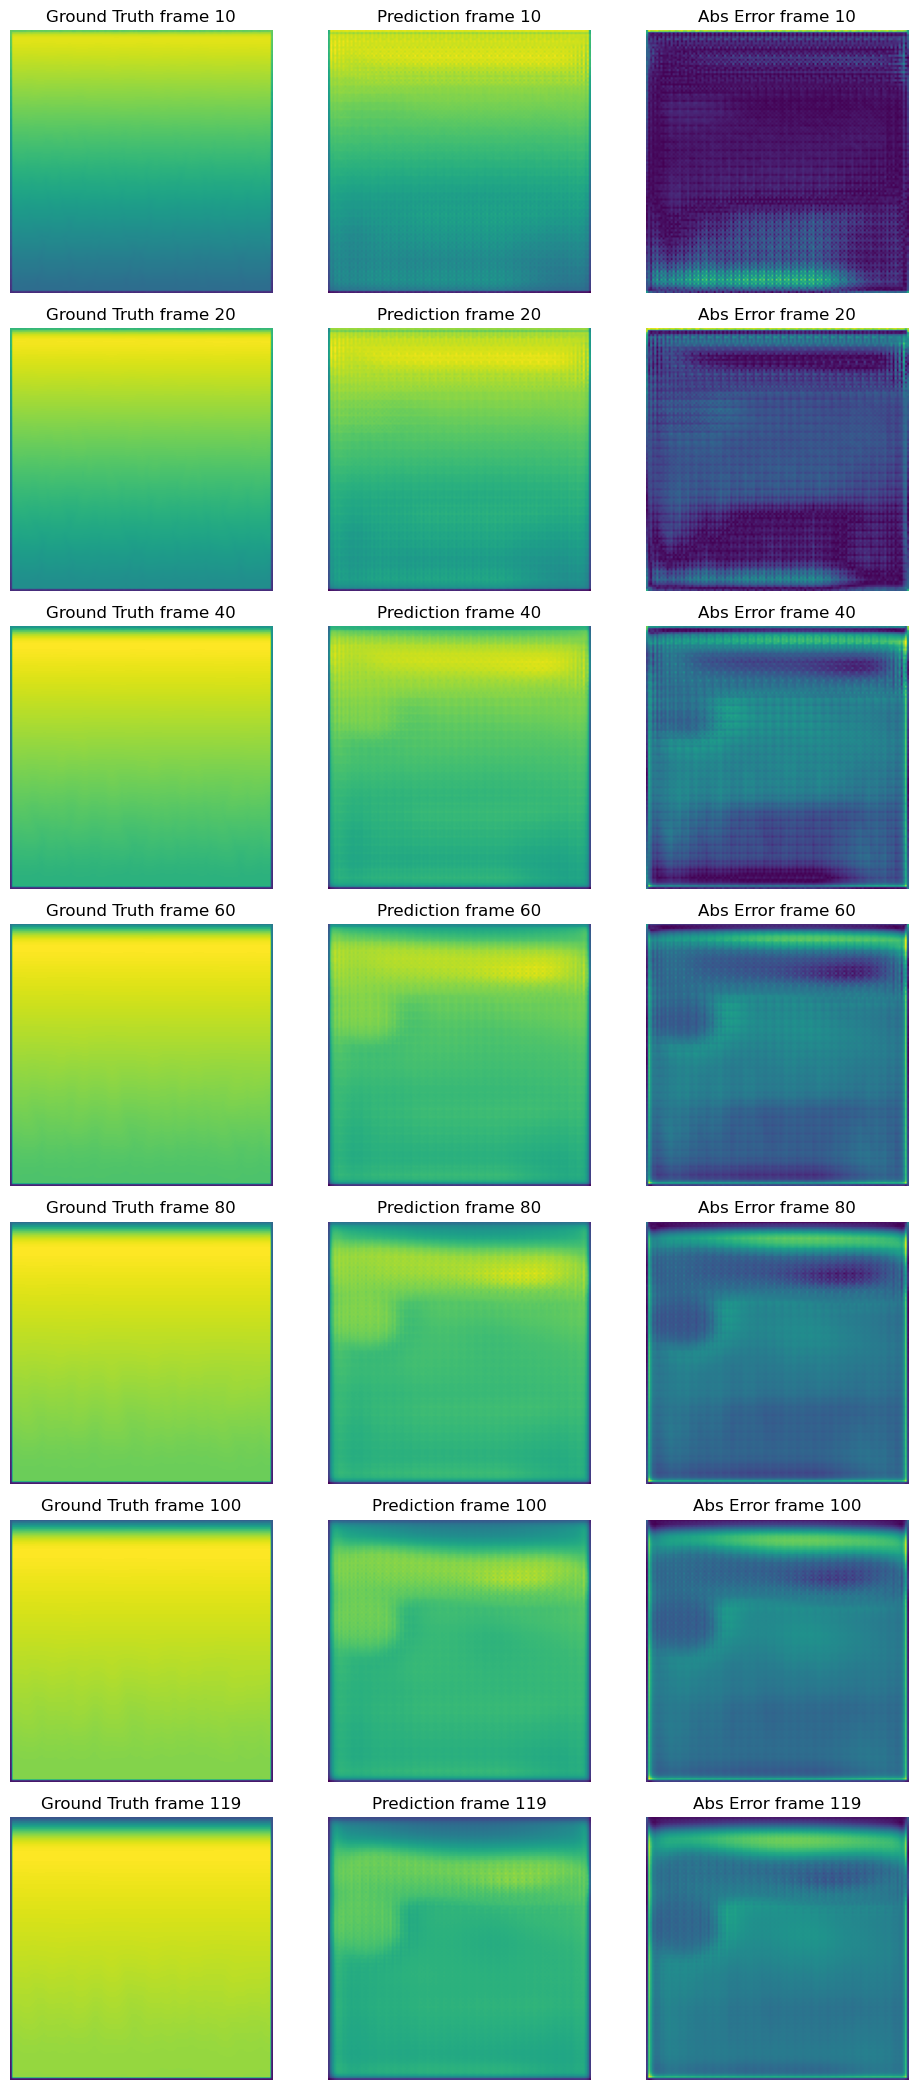

In [7]:
# Visualization

show_frames = [10, 20, 40, 60, 80, 100, 119]
show_indices = [f - 10 for f in show_frames]

fig, axes = plt.subplots(len(show_indices), 3, figsize=(10, 3 * len(show_indices)))

for row, idx in enumerate(show_indices):
    gt = target_110_cpu[idx, 0].numpy()
    pr = pred_110_cpu[idx, 0].numpy()
    err = np.abs(pr - gt)

    vmin = min(gt.min(), pr.min())
    vmax = max(gt.max(), pr.max())

    axes[row, 0].imshow(gt, vmin=vmin, vmax=vmax)
    axes[row, 0].set_title(f"Ground Truth frame {show_frames[row]}")

    axes[row, 1].imshow(pr, vmin=vmin, vmax=vmax)
    axes[row, 1].set_title(f"Prediction frame {show_frames[row]}")

    axes[row, 2].imshow(err)
    axes[row, 2].set_title(f"Abs Error frame {show_frames[row]}")

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Cell: save 110-frame rollout arrays

# pred_110_cpu:   (110, 1, H, W)
# target_110_cpu: (110, 1, H, W)
# mse_per_frame_110: (110,)

mae_per_frame_110 = torch.abs(
    pred_110_cpu - target_110_cpu
).mean(dim=(1, 2, 3)).numpy()

np.save(
    os.path.join(save_dir, "pred_110.npy"),
    pred_110_cpu.numpy()
)

np.save(
    os.path.join(save_dir, "target_110.npy"),
    target_110_cpu.numpy()
)

np.save(
    os.path.join(save_dir, "mse_per_frame_110.npy"),
    mse_per_frame_110
)

np.save(
    os.path.join(save_dir, "mae_per_frame_110.npy"),
    mae_per_frame_110
)

print("Saved 110-frame rollout arrays to:", save_dir)
print("pred_110.npy shape:", pred_110_cpu.numpy().shape)
print("target_110.npy shape:", target_110_cpu.numpy().shape)
print("mse_per_frame_110.npy shape:", mse_per_frame_110.shape)
print("mae_per_frame_110.npy shape:", mae_per_frame_110.shape)

Saved 110-frame rollout arrays to: simvp_zonly_results_stride5
pred_110.npy shape: (110, 1, 128, 128)
target_110.npy shape: (110, 1, 128, 128)
mse_per_frame_110.npy shape: (110,)
mae_per_frame_110.npy shape: (110,)
